We use 4 LLMs: OpenAI, Anthropic Claude, Mistral, Cohere

In [ ]:
!pip -q install openai anthropic cohere pandas tqdm scikit-learn requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.6/753.6 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.5/350.5 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 70.6 MB/s eta 0:00:00


In [ ]:
import os
from getpass import getpass
import json
import re
import time
import requests
import pandas as pd

from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MultiLabelBinarizer

from openai import OpenAI
from anthropic import Anthropic
import cohere

os.environ["OPENAI_API_KEY"] = getpass("OpenAI API key: ").strip()
os.environ["ANTHROPIC_API_KEY"] = getpass("Anthropic API key: ").strip()
os.environ["MISTRAL_API_KEY"] = getpass("Mistral API key: ").strip()
os.environ["COHERE_API_KEY"] = getpass("Cohere API key: ").strip()

openai_client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
anthropic_client = Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])
cohere_client = cohere.ClientV2(
    api_key=os.environ["COHERE_API_KEY"],
    log_warning_experimental_features=False
)

test_df = pd.read_csv("test_df.csv", sep=";")
unlabeled_df = pd.read_csv("unlabeled_df.csv", sep=";")

OpenAI API key: ··········
Anthropic API key: ··········
Mistral API key: ··········
Cohere API key: ··········


In [ ]:
def extract_json(raw_text):
    if raw_text is None:
        return {
            "strategy1": None,
            "strategy2": None,
            "confidence": None,
            "explanation": "Empty response"
        }

    raw_text = str(raw_text).strip()
    raw_text = raw_text.replace("```json", "").replace("```", "").strip()

    try:
        return json.loads(raw_text)
    except json.JSONDecodeError:
        pass

    match = re.search(r"\{.*\}", raw_text, flags=re.DOTALL)

    if match:
        try:
            return json.loads(match.group(0))
        except json.JSONDecodeError:
            pass

    return {
        "strategy1": None,
        "strategy2": None,
        "confidence": None,
        "explanation": f"Could not parse JSON: {raw_text[:300]}"
    }

In [ ]:
ANNOTATION_PROMPT = """You are an expert annotator of rhetorical strategies in American presidential and vice-presidential debate transcripts.
## Your task
Given a speech fragment, assign one primary rhetorical strategy (strategy1). Assign strategy2 only in rare cases when two strategies are equally and clearly present.
## Taxonomy

1. 'presentation' (positive framing, self-presentation) - speaker explicitly represents themselves, their party, their candidate, situation, event, policy outcome, or trend in a positive light. Positive evaluation of a situation counts as presentation only when the speaker associates the positive outcome with their own side (their party, administration, or policy).
2. 'accusation' (negative framing of others) - speaker attributes blame or wrongdoing to an opponent, or describes a situation, event, or trend negatively while attributing the cause to a specific actor (opponent, opposing party, current administration). Includes alleging specific improper actions, lies, or intentions. A neutral statement of a problem within the speaker's own program is not accusation.
3. 'self-justification' - speaker can either explain and provide context for an action, decision, or record, or deny and reject an accusation. Apply only when the speaker's main rhetorical move is to deny, explain, or contextualize a specific accusation against themselves or their record. If the speaker pivots to attacking the opponent or laying out their own positive program, use accusation or presentation instead.
4. 'appeal' - an audience-oriented rhetorical move: a direct call to the audience to act, vote, support, or adopt a position, OR a broader appeal that invokes shared values, identity, or collective responsibility ("we as a nation must...", "we need to..."), OR emotional storytelling addressed to the audience to mobilize support for a stance. The defining feature is audience orientation, not just programmatic content.
Special labels:
- '-' - moderator or question-asker utterance.
- 'no_strategy' - fragment is too short, interrupted, purely emotional, procedural, or lacks sufficient context to identify a strategy (broken-off thoughts, one-word interjections, simple acknowledgments like "thank you", "yes", "well", procedural requests like "May I respond?", "Can I have a rebuttal?").
## Decision procedure
Apply these checks in order:
1. Is this a moderator/question-asker? → strategy1 = "-", strategy2 = null. Stop.
2. Is the fragment too short, interrupted, purely emotional, or procedural? → strategy1 = "no_strategy", strategy2 = null. Stop.
3. Is the speaker's main rhetorical move to deny, explain, or contextualize a specific accusation against themselves or their record? → "self-justification". (If the speaker pivots to attacking the opponent or laying out their own positive program, skip this step.)
4. Is the speaker explicitly praising a named person/party (themselves, running mate, their party), or positively evaluating a situation/outcome that they associate with their own side? → "presentation"
5. Is the speaker explicitly blaming a named opponent, or negatively describing a situation/trend while attributing the cause to a specific actor (opponent, opposing party, current administration)? → "accusation"
6. Is the speaker addressing the audience — calling them to act/vote/decide, invoking shared values or collective responsibility ("we as a nation must..."), or using emotional storytelling to mobilize support? → "appeal"
## Rules for strategy2
**Default: strategy2 should be null.** Most fragments have one dominant strategy. Only assign strategy2 when both strategies are EQUALLY prominent in the fragment.
The most common legitimate dual case is 'accusation' + 'presentation': the speaker explicitly contrasts the opponent's failures with their own/their party's achievements in the same fragment, with both halves substantively developed.
Do NOT assign strategy2 when:
- One strategy is clearly dominant and the other is only briefly hinted at
- You are merely uncertain between two strategies - pick the better one for strategy1, leave strategy2 null
- The fragment expresses a single coherent rhetorical move
If only one strategy applies, set strategy2 to null.
## Output format
Return strictly valid JSON, no extra text:
{
  "strategy1": "...",
  "strategy2": "..." or null,
  "confidence": 0.0-1.0,
  "explanation": "one sentence explaining the choice"
}

## Examples
Text: "We need real results and we need them now. I've done that in my whole career and I'll do it as president."
{"strategy1": "presentation", "strategy2": null, "confidence": 0.9, "explanation": "The speaker explicitly presents themselves as a concrete actor with a track record of delivering results throughout their career."}

Text: "No, check out the deal that they signed with Judicial Watch. They agreed that that many people either voted illegally, shouldn't have been voting, a lot of things. … But they play a very dirty game."
{"strategy1": "accusation", "strategy2": null, "confidence": 0.9, "explanation": "The speaker explicitly blames a specific opponent of illegal voting practices and concludes with a direct negative characterization ('they play a very dirty game')."}

Text: "They had the slowest economic recovery since 1929. It was the slowest recovery. Also, they took over something that was down here. All you had to do is turn on the lights and you pick up a lot. But they had the slowest economic recovery since 1929."
{"strategy1": "accusation", "strategy2": null, "confidence": 0.85, "explanation": "The speaker negatively describes the economic recovery and attributes it to a specific actor ('they' = previous administration), with repeated emphasis on the negative characterization."}

Text: "Tonight, I am also asking you to join me in another fight that all Americans can get behind: the fight against childhood cancer."
{"strategy1": "appeal", "strategy2": null, "confidence": 0.9, "explanation": "The speaker directly calls on the audience ('I am asking you to join me') to take a particular action - supporting the fight against childhood cancer."}

Text: "We must be united at home to defeat our adversaries abroad."
{"strategy1": "appeal", "strategy2": null, "confidence": 0.9, "explanation": "The speaker appeals to shared values through inclusive 'we' rhetoric and frames national unity as a collective necessity."}

Text: "Those pre-existing conditions, insurance companies are going to love this. And so it's just not appropriate to do this before this election. … Number one, he knows what I proposed. What I proposed is that we expand Obamacare and we increase it. We do not wipe any. … The platform of the Democratic Party is what I, in fact, approved of, what I approved of. Now, here's the deal. The deal is that it's going to wipe out pre-existing conditions."
{"strategy1": "self-justification", "strategy2": null, "confidence": 0.85, "explanation": "The speaker defends their own healthcare policy stance by clarifying what they actually proposed and explaining their relationship to the party platform, rather than disputing that any action took place."}

Text: "He's absolutely wrong, number one. Number two, if in fact, during our administration in the recovery act, I was in charge able to bring down the cost of renewable energy to cheaper than are as cheap as coal and gas and oil. Nobody's going to build another coal fired plant in America. No one's going to build another oil fire plant in America."
{"strategy1": "self-justification", "strategy2": null, "confidence": 0.9, "explanation": "The speaker directly rejects the opponent's accusation and supports the denial by pointing to a concrete achievement during their administration."}

Text: "… we inherited the worst recession, short of a depression in American history. I was asked to bring it back. We were able to have an economic recovery that created the jobs you're talking about. We handed him a booming economy, he blew it."
{"strategy1": "accusation", "strategy2": "presentation", "confidence": 0.9, "explanation": "The speaker positively presents their own administration's economic record ('we were able to', 'we handed him a booming economy') and contrasts it with a direct accusation that the opponent ruined it ('he blew it')."}

Text: "Well, I must admit, it surprised me tonight. We're seeing all over this nation, all cities and all parts of the country, indeed across the world, an outpouring of joy, of hope, renewed faith in tomorrow to bring a better day."
{"strategy1": "presentation", "strategy2": null, "confidence": 0.65, "explanation": "The speaker positively evaluates the current situation by describing widespread joy, hope, and renewed faith without attributing this positive state to any specific actor."}

Text: "I appreciate that."
{"strategy1": "no_strategy", "strategy2": null, "confidence": 0.9, "explanation": "Short acknowledgment of an opponent's remark with no rhetorical content."}

"""

In [ ]:
def annotate_mistral(row, model="mistral-small-latest"):
    url = "https://api.mistral.ai/v1/chat/completions"

    headers = {
        "Authorization": f"Bearer {os.environ['MISTRAL_API_KEY']}",
        "Content-Type": "application/json"
    }

    payload = {
        "model": model,
        "temperature": 0,
        "messages": [
            {"role": "system", "content": ANNOTATION_PROMPT},
            {"role": "user", "content": row["text"]}
        ],
        "response_format": {
            "type": "json_object"
        }
    }

    r = requests.post(url, headers=headers, json=payload, timeout=90)
    r.raise_for_status()

    data = r.json()
    raw_text = data["choices"][0]["message"]["content"]

    return extract_json(raw_text)

In [ ]:
ANNOTATION_SCHEMA = {
    "type": "object",
    "required": ["strategy1", "confidence", "explanation"],
    "properties": {
        "strategy1": {
            "type": "string",
            "enum": ["presentation", "accusation", "self-justification", "appeal", "-", "no_strategy"]
        },
        "strategy2": {
            "anyOf": [
                {
                    "type": "string",
                    "enum": ["presentation", "accusation", "self-justification", "appeal", "no_strategy"]},
                {"type": "null"}
            ]
        },
        "confidence": {
            "type": "number"
        },
        "explanation": {
            "type": "string"
        }
    }
}


def annotate_cohere(row, model='command-a-03-2025'):
    response = cohere_client.chat(
        model=model,
        messages=[
            {'role': 'system', 'content': ANNOTATION_PROMPT},
            {'role': 'user', 'content': f"Annotate this fragment and return a JSON object:\n\n{row['text']}"}
        ],
        temperature=0,
        max_tokens=300,
        response_format={
            "type": "json_object",
            "schema": ANNOTATION_SCHEMA
        }
    )

    raw_text = response.message.content[0].text
    return extract_json(raw_text)

In [ ]:
OPENAI_SCHEMA = {
    "type": "object",
    "properties": {
        "strategy1": {
            "type": "string",
            "enum": ["presentation", "accusation", "self-justification", "appeal", "-", "no_strategy"]
        },
        "strategy2": {
            "type": ["string", "null"],
            "enum": ["presentation", "accusation", "self-justification", "appeal", "no_strategy", None]
        },
        "confidence": {"type": "number"},
        "explanation": {"type": "string"}
    },
    "required": ["strategy1", "strategy2", "confidence", "explanation"],
    "additionalProperties": False
}


def annotate_openai(row, model="gpt-5"):
    response = openai_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": ANNOTATION_PROMPT},
            {"role": "user", "content": row["text"]}
        ],
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "strategy_annotation",
                "strict": True,
                "schema": OPENAI_SCHEMA
            }
        }
    )

    raw_text = response.choices[0].message.content
    return extract_json(raw_text)

In [ ]:
ANTHROPIC_TOOL = {
    "name": "annotate_strategy",
    "description": "Record the rhetorical strategy annotation for a debate fragment.",
    "input_schema": {
        "type": "object",
        "properties": {
            "strategy1": {
                "type": "string",
                "enum": ["presentation", "accusation", "self-justification", "appeal", "-", "no_strategy"]
            },
            "strategy2": {
                "type": "string",
                "enum": ["presentation", "accusation", "self-justification", "appeal", "no_strategy", "none"]
            },
            "confidence": {"type": "number"},
            "explanation": {"type": "string"}
        },
        "required": ["strategy1", "strategy2", "confidence", "explanation"],
        "additionalProperties": False
    }
}


def annotate_anthropic(row, model="claude-sonnet-4-5"):
    response = anthropic_client.messages.create(
        model=model,
        max_tokens=300,
        temperature=0,
        system=ANNOTATION_PROMPT,
        messages=[
            {"role": "user", "content": row["text"]}
        ],
        tools=[ANTHROPIC_TOOL],
        tool_choice={"type": "tool", "name": "annotate_strategy"}
    )

    tool_use = next(
        block for block in response.content if block.type == "tool_use"
    )
    result = dict(tool_use.input)
    if result.get("strategy2") == "none":
        result["strategy2"] = None
    return result

In [ ]:
def normalize_label(x):
    if pd.isna(x):
        return "-"
    x = str(x).strip().lower()

    if x in ["", "nan", "none", "null"]:
        return "-"

    return x

def to_strategy_set(t1, t2):
    strategies = set()
    for t in [t1, t2]:
        if pd.notna(t):
            t_norm = str(t).strip().lower()
            if t_norm not in ['', 'nan', 'none', 'null', '-']:
                strategies.add(t_norm)
    return strategies


def evaluate_model(result_df, model_name):
    pred_col_1 = f"{model_name}_strategy1"
    pred_col_2 = f"{model_name}_strategy2"

    eval_df = result_df.copy()

    # Множества тактик (порядконезависимые)
    eval_df['gold_set'] = eval_df.apply(
        lambda r: to_strategy_set(r['gold_strategy1'], r['gold_strategy2']), axis=1
    )
    eval_df[f'{model_name}_set'] = eval_df.apply(
        lambda r: to_strategy_set(r[pred_col_1], r[pred_col_2]), axis=1
    )

    eval_df["gold_strategy1_norm"] = eval_df["gold_strategy1"].apply(normalize_label)
    eval_df[f"{model_name}_strategy1_norm"] = eval_df[pred_col_1].apply(normalize_label)
    eval_df["strategy1_match"] = (
        eval_df["gold_strategy1_norm"] == eval_df[f"{model_name}_strategy1_norm"]
    )

    eval_df['exact_set_match'] = eval_df['gold_set'] == eval_df[f'{model_name}_set']

    # Primary strategy recall: попала ли gold-первая тактика в предсказанный набор
    def primary_in_pred(row):
        gold_primary = row['gold_strategy1_norm']
        if gold_primary in ['-', '']:
            return None
        return gold_primary in row[f'{model_name}_set']

    eval_df['primary_recall'] = eval_df.apply(primary_in_pred, axis=1)

    metrics = {
        "model": model_name,
        "n": len(eval_df),
        "strategy1_strict_accuracy": eval_df["strategy1_match"].mean(),
        "exact_set_accuracy": eval_df["exact_set_match"].mean(),
        "primary_strategy_recall": eval_df['primary_recall'].dropna().mean(),
        "errors": eval_df[f"{model_name}_error"].notna().sum()
    }

    return metrics, eval_df

In [ ]:
TEST_LINKS = [
    'https://www.presidency.ucsb.edu/documents/vice-presidential-debate-new-york-city',
    'https://www.presidency.ucsb.edu/documents/vice-presidential-debate-houston-texas',
    'https://www.presidency.ucsb.edu/documents/presidential-debate-hofstra-university-hempstead-new-york',
    'https://www.presidency.ucsb.edu/ws/index.php?pid=105444',
]


test_to_annotate = unlabeled_df[
    (unlabeled_df['link'].isin(TEST_LINKS)) &
    (unlabeled_df['strategy1'].isna())
].copy()

print(f"Строк для разметки: {len(test_to_annotate)}")

Строк для разметки: 354


In [ ]:
# Запуск Mistral
mistral_results = []
for _, row in tqdm(test_to_annotate.iterrows(), total=len(test_to_annotate), desc="Mistral"):
    try:
        result = annotate_mistral(row)
        result["error"] = None
    except Exception as e:
        result = {"strategy1": None, "strategy2": None, "confidence": None, "explanation": None, "error": str(e)}
    mistral_results.append(result)
    time.sleep(3)

Mistral: 100%|██████████| 354/354 [23:29<00:00,  3.98s/it]


In [ ]:
# Запуск Cohere
cohere_results = []
for _, row in tqdm(test_to_annotate.iterrows(), total=len(test_to_annotate), desc="Cohere"):
    try:
        result = annotate_cohere(row)
        result["error"] = None
    except Exception as e:
        result = {"strategy1": None, "strategy2": None, "confidence": None, "explanation": None, "error": str(e)}
    cohere_results.append(result)

Cohere: 100%|██████████| 354/354 [12:10<00:00,  2.06s/it]


In [ ]:
# Запуск OpenAI
openai_results = []
for _, row in tqdm(test_to_annotate.iterrows(), total=len(test_to_annotate), desc="OpenAI"):
    try:
        result = annotate_openai(row)
        result["error"] = None
    except Exception as e:
        result = {"strategy1": None, "strategy2": None, "confidence": None, "explanation": None, "error": str(e)}
    openai_results.append(result)

OpenAI: 100%|██████████| 354/354 [57:45<00:00,  9.79s/it]


In [ ]:
# Запуск Anthropic
anthropic_results = []
for _, row in tqdm(test_to_annotate.iterrows(), total=len(test_to_annotate), desc="Anthropic"):
    try:
        result = annotate_anthropic(row)
        result["error"] = None
    except Exception as e:
        result = {"strategy1": None, "strategy2": None, "confidence": None, "explanation": None, "error": str(e)}
    anthropic_results.append(result)

Anthropic: 100%|██████████| 354/354 [34:12<00:00,  5.80s/it]


In [ ]:
result_df = test_to_annotate[["link", "order", "text", "speaker"]].copy()

for col in ["strategy1", "strategy2", "confidence", "explanation", "error"]:
    result_df[f"mistral_{col}"] = [r.get(col) for r in mistral_results]
    result_df[f"cohere_{col}"] = [r.get(col) for r in cohere_results]
    result_df[f"openai_{col}"] = [r.get(col) for r in openai_results]
    result_df[f"anthropic_{col}"] = [r.get(col) for r in anthropic_results]

gold = test_df[["link", "order", "strategy1", "strategy2"]].rename(
    columns={"strategy1": "gold_strategy1", "strategy2": "gold_strategy2"}
)
result_df = result_df.merge(gold, on=["link", "order"], how="left")

In [ ]:
MODELS = ["mistral", "cohere", "openai", "anthropic"]
EMPTY_VALUES = {"", "nan", "none", "null"}

def clean_value(x):
    if pd.isna(x):
        return pd.NA
    if str(x).strip().lower() in EMPTY_VALUES:
        return pd.NA
    return x

def normalize_strategy_value(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    if s in EMPTY_VALUES or s == "-":
        return None
    return s

def reorder_accusation_presentation(s1, s2):
    n1, n2 = normalize_strategy_value(s1), normalize_strategy_value(s2)
    if {n1, n2} == {"accusation", "presentation"}:
        return "accusation", "presentation"
    return s1, s2

def reorder_pair_in_df(df, col1, col2):
    new_pairs = df.apply(
        lambda row: reorder_accusation_presentation(row[col1], row[col2]),
        axis=1,
    )
    df[col1] = [p[0] for p in new_pairs]
    df[col2] = [p[1] for p in new_pairs]

for model in MODELS:
    result_df[f"{model}_strategy1"] = result_df[f"{model}_strategy1"].apply(clean_value)
    result_df[f"{model}_strategy2"] = result_df[f"{model}_strategy2"].apply(clean_value)

result_df["gold_strategy1"] = result_df["gold_strategy1"].apply(clean_value)
result_df["gold_strategy2"] = result_df["gold_strategy2"].apply(clean_value)

for model in MODELS:
    reorder_pair_in_df(result_df, f"{model}_strategy1", f"{model}_strategy2")

reorder_pair_in_df(result_df, "gold_strategy1", "gold_strategy2")

In [ ]:
result_df_eval = result_df[
    (result_df['gold_strategy1'].notna()) &
    (result_df['gold_strategy1'] != '-')
].copy()

mistral_metrics, mistral_eval = evaluate_model(result_df_eval, "mistral")
cohere_metrics, cohere_eval = evaluate_model(result_df_eval, "cohere")
openai_metrics, openai_eval = evaluate_model(result_df_eval, "openai")
anthropic_metrics, anthropic_eval = evaluate_model(result_df_eval, "anthropic")

comparison = pd.DataFrame([
    mistral_metrics, cohere_metrics, openai_metrics, anthropic_metrics
])
comparison = comparison.set_index("model")
print(comparison.to_string())

             n  strategy1_strict_accuracy  exact_set_accuracy  primary_strategy_recall  errors
model                                                                                         
mistral    353                   0.827195            0.745042                 0.841360       0
cohere     353                   0.838527            0.759207                 0.855524       0
openai     353                   0.821530            0.745042                 0.847025       0
anthropic  353                   0.824363            0.759207                 0.881020       4


In [ ]:
ALL_STRATEGIES = ['presentation', 'accusation', 'self-justification', 'appeal', 'no_strategy']

evals = {
    "mistral": mistral_eval,
    "cohere": cohere_eval,
    "openai": openai_eval,
    "anthropic": anthropic_eval,
}

mlb = MultiLabelBinarizer(classes=ALL_STRATEGIES)
mlb.fit([ALL_STRATEGIES])

for model_name, eval_df in evals.items():
    print(f"\n{'='*60}")
    print(f"Multi-label classification report — {model_name}")
    print('='*60)

    y_true = mlb.transform(eval_df['gold_set'])
    y_pred = mlb.transform(eval_df[f'{model_name}_set'])

    print(classification_report(
        y_true, y_pred,
        target_names=ALL_STRATEGIES,
        zero_division=0
    ))


Multi-label classification report — mistral
                    precision    recall  f1-score   support

      presentation       0.73      0.87      0.79       120
        accusation       0.94      0.79      0.86       128
self-justification       0.74      0.66      0.70        47
            appeal       0.66      0.86      0.75        36
       no_strategy       0.92      0.94      0.93        89

         micro avg       0.82      0.84      0.83       420
         macro avg       0.80      0.82      0.81       420
      weighted avg       0.83      0.84      0.83       420
       samples avg       0.83      0.84      0.82       420


Multi-label classification report — cohere
                    precision    recall  f1-score   support

      presentation       0.86      0.82      0.84       120
        accusation       0.88      0.88      0.88       128
self-justification       0.79      0.81      0.80        47
            appeal       0.69      0.50      0.58        36
       

In [ ]:
result_df.to_csv("few_shot_results.csv", index=False, sep=";")
comparison.to_csv("few_shot_comparison.csv", sep=";")

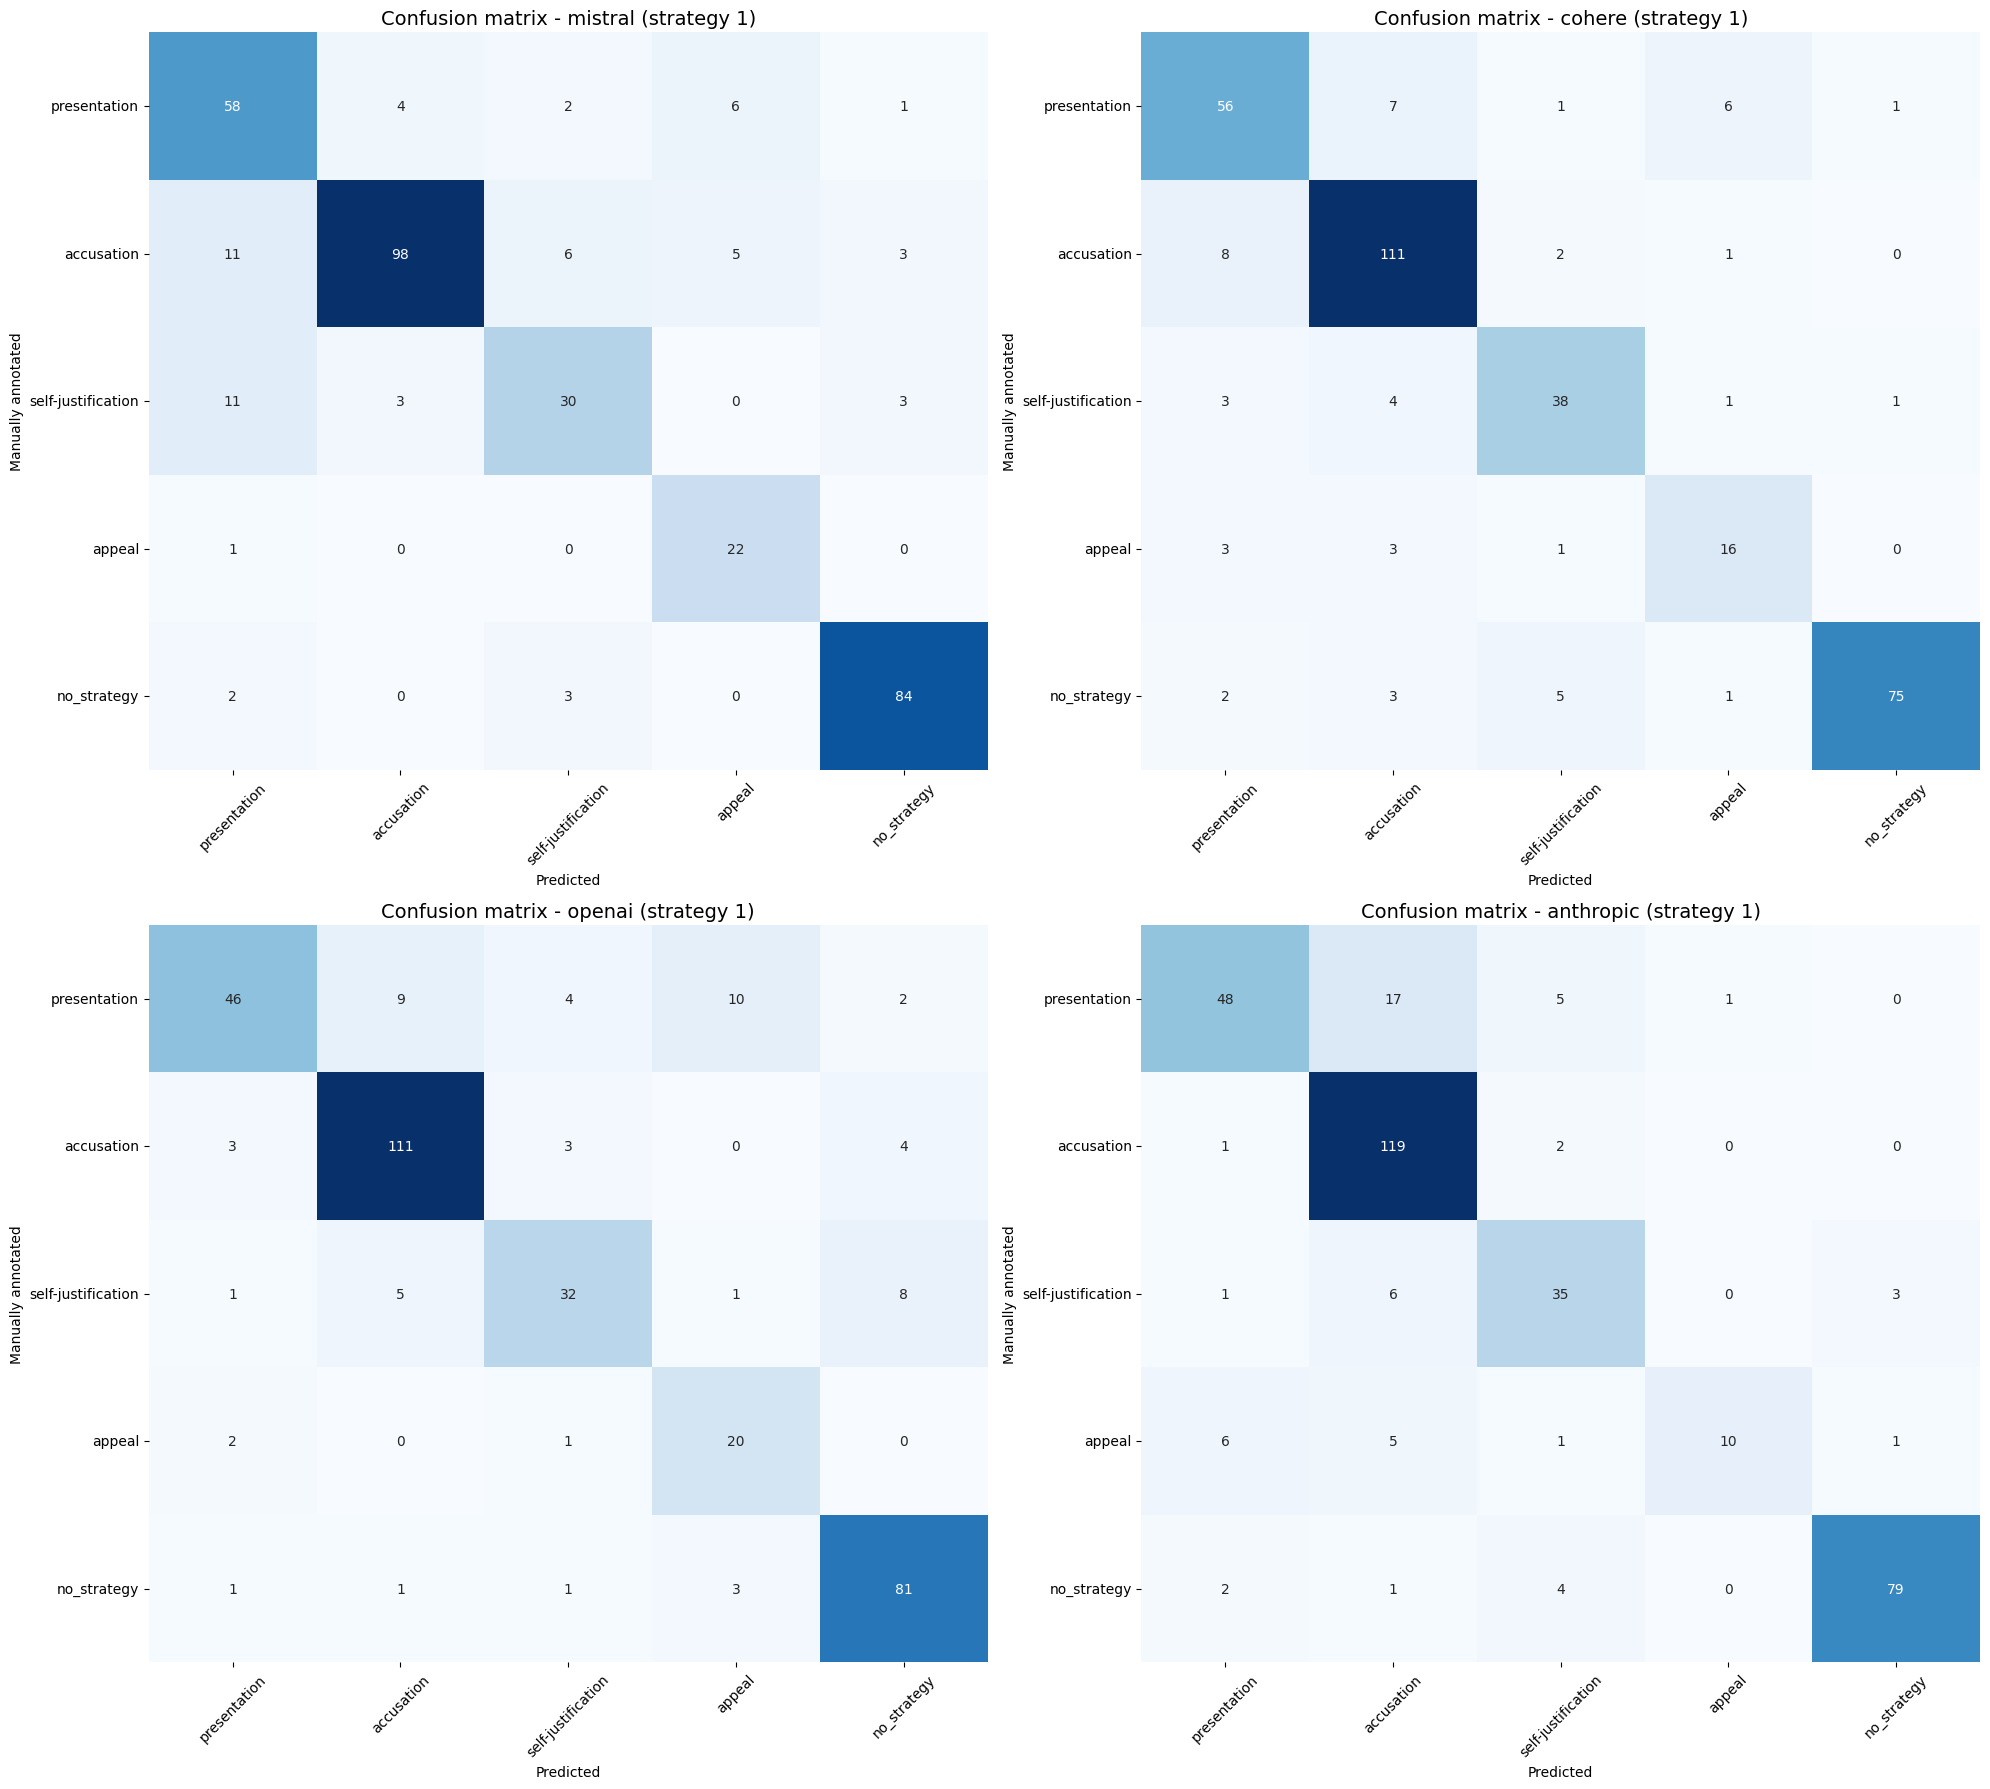

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(20, 18))
axes = axes.flatten()

for idx, (model_name, eval_df) in enumerate(evals.items()):
    y_true = eval_df["gold_strategy1_norm"]
    y_pred = eval_df[f"{model_name}_strategy1_norm"]

    cm = confusion_matrix(y_true, y_pred, labels=ALL_STRATEGIES)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=ALL_STRATEGIES,
        yticklabels=ALL_STRATEGIES,
        ax=axes[idx],
        cbar=False
    )
    axes[idx].set_title(f"Confusion matrix - {model_name} (strategy 1)", fontsize=14)
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Manually annotated")
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig("few_shot_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()